In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from ipywidgets import interact, FloatSlider, IntSlider

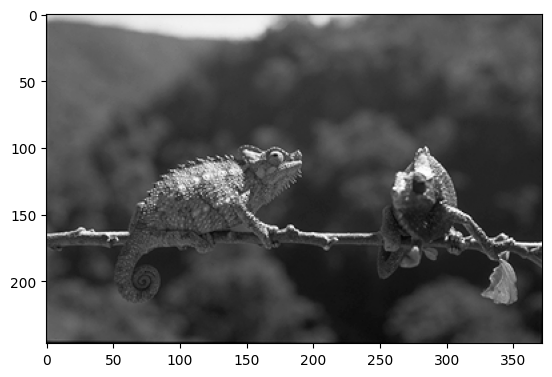

In [2]:
img = cv2.imread("../Imagenes_cursado/camaleon.tif", cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap = 'gray')
plt.show()

# Filtrado de alta potencia

In [3]:
def filtrado_alta_potencia(img, r, A, n):

    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2

    f = np.fft.fft2(img)
    f_shift = np.fft.fftshift(f)

    y, x = np.ogrid[:rows, :cols]
    dist_from_center = np.sqrt((x - ccol)**2 +(y - crow)**2)

    h_pa = 1 / (1 +(r / (dist_from_center + 1e-8))**(2 * n))
    h_ap = (A - 1) + h_pa

    f_filtrada = f_shift * h_ap
    img_back = np.fft.ifft2(np.fft.ifftshift(f_filtrada))
    img_final = np.real(img_back)

    return img_final, h_ap


def visualizacion_alta_potencia(r, A, n):
    plt.close('all')

    res, mascara = filtrado_alta_potencia(img,r,A,n)
    plt.figure(figsize=(18,6))
    plt.suptitle(r"Filtrado Alta Potencia: "r"$H_{AP}(u,v) = (A - 1) + H_{PA}(u,v)$",fontsize=16)
    plt.subplot(1,3,1)
    plt.imshow(img,cmap='gray')

    plt.title("Imagen Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(res,cmap='gray',vmin=np.min(img),vmax=np.max(img))

    plt.title(f"Resultado (A={A}, n={n})")
    plt.axis('off')

    plt.subplot(1,3,3)
    im_mask = plt.imshow(mascara,cmap='viridis')

    plt.title(f"Filtro H(u,v) - Radio: {r}")

    plt.colorbar(im_mask,fraction=0.046,pad=0.04)

    plt.axis('off')
    plt.tight_layout()
    plt.show()


interact(visualizacion_alta_potencia,
        r=IntSlider(min=1,max=100,step=1,value=20,description='Radio D0'),
        A=FloatSlider(min=1.0,max=5.0,step=0.1,value=1.5,description='A'),
        n=IntSlider(min=1,max=5,step=1,value=2,description='Orden n')
        )

interactive(children=(IntSlider(value=20, description='Radio D0', min=1), FloatSlider(value=1.5, description='…

<function __main__.visualizacion_alta_potencia(r, A, n)>

No entienod porque me pone tantos graficos, no pasaba esto antes de la entrega!

# Filtrado de enfasis

In [4]:
def filtrado_enfasis(img, r, a,b, n):
    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2

    f = np.fft.fft2(img) #le saco la transformada de fourier a la img
    f_shift = np.fft.fftshift(f) #la centro

    #creamos alguna mascara pasa altos por ejemplo la ideal
    y, x = np.ogrid[:rows, :cols]
    dist_from_center = np.sqrt((x - ccol)**2 + (y - crow)**2)
    h_pa = 1 / (1 + (r / (dist_from_center + 1e-8))**(2 * n))

    h_enfasis = a + b * h_pa

    f_filtrada = f_shift * h_enfasis
    img_back = np.fft.ifft2(np.fft.ifftshift(f_filtrada))
    img_final = np.real(img_back)

    return img_final, h_enfasis

def visualizacion_enfasis(r, a, b, n):
    plt.close('all')
    res, mascara = filtrado_enfasis(img, r, a, b, n)
    
    plt.figure(figsize=(18, 6))
    plt.suptitle(f"Énfasis Butterworth: $H(u,v) = a + b \cdot H_a(u,v)$", fontsize=16)
    
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Imagen Original")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(res, cmap='gray', vmin=np.min(img), vmax=np.max(img))
    plt.title(f"Resultado (n={n})")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    im_mask = plt.imshow(mascara, cmap='viridis')
    plt.title(f"Filtro H(u,v) - Radio: {r}")
    plt.colorbar(im_mask, fraction=0.046, pad=0.04)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Llamada interactiva corregida
interact(visualizacion_enfasis, 
         r=IntSlider(min=1, max=100, step=1, value=20, description='Radio (D0)'),
         a=FloatSlider(min=0.0, max=2.0, step=0.1, value=0.5, description='a (Offset)'),
         b=FloatSlider(min=0.0, max=5.0, step=0.1, value=1.5, description='b (Ganancia)'),
         n=IntSlider(min=1, max=5, step=1, value=2, description='Orden n'))

<>:26: SyntaxWarning: invalid escape sequence '\c'
<>:26: SyntaxWarning: invalid escape sequence '\c'
C:\Users\MATEOCRACK\AppData\Local\Temp\ipykernel_1264\3857579682.py:26: SyntaxWarning: invalid escape sequence '\c'
  plt.suptitle(f"Énfasis Butterworth: $H(u,v) = a + b \cdot H_a(u,v)$", fontsize=16)


interactive(children=(IntSlider(value=20, description='Radio (D0)', min=1), FloatSlider(value=0.5, description…

<function __main__.visualizacion_enfasis(r, a, b, n)>